# Real, or the usual wobble?

**Week 1, Thursday. Chapter 1 of 6.** By the end of this notebook you can run a shuffle test on
two quarters, read its share as a p-value, choose between four ways of asking "is it real?", and
reach the same verdict a second way.

> **The client asks.** "Retail-Plus is down, smaller than first reported. Real, or the wobble we see
> every quarter?"
>
> Meera Raghavan, CEO, Kalpa Retail

**The metric at stake.** Delivered revenue per Retail-Plus member per quarter. Retail-Plus is
Kalpa's membership tier, the customers who buy most often (the domain dossier,
`content/W01/D1/study-notes/C2_W01_D01_domain_retail_STUDENT.md`, tells its story). **Who asks and
what rides on it.** Meera, before Monday's growth review: a real fall opens a retention budget for
the tier, and a wobble read as real spends that budget chasing noise. **Who else faces it.**
Booking.com runs about 25,000 tests a year and, by the account of the Harvard researcher who
studied it, its teams are wrong about nine times in ten, so every change there is read against
what chance alone produces before anyone acts (the sources are in the study notes).

Wednesday reconciled the quarters with Finance and left Retail-Plus standing, but smaller. This
chapter asks whether what is left is bigger than chance makes on its own.

**Setup.** Find the helper and load the cleaned two quarters. Three helpers start the day's
toolkit: `member_totals` turns orders into one number per member, `shuffle_gaps` deals the numbers
to two piles at random, and `share_at_least` counts how many chance-only worlds match the real gap.
Every later chapter carries these forward and adds one of its own.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import random
import time

ORDERS = kit.load_csv("C2_W01_D04_orders_STUDENT.csv")
SEGMENTS = ["Retail-Core", "Retail-Plus", "Student", "Business"]


def mean(values):
    return sum(values) / len(values)


def member_totals(segment, quarter):
    """Delivered revenue per member of one segment in one quarter, one number per member."""
    members = sorted({o["customer_id"] for o in ORDERS if o["segment"] == segment})
    totals = {m: 0 for m in members}
    for o in ORDERS:
        if o["segment"] == segment and o["quarter"] == quarter and o["status"] == "delivered":
            totals[o["customer_id"]] += int(o["amount"])
    return [totals[m] for m in members]


def shuffle_gaps(q1, q2, times, seed):
    """Deal the pooled values to two piles at random, many times, and keep each gap."""
    random.seed(seed)                  # the same shuffles on every laptop
    pool = q1 + q2                     # all the cards, labels ignored
    gaps = []
    for _ in range(times):
        random.shuffle(pool)           # deal at random
        gaps.append(mean(pool[:len(q1)]) - mean(pool[len(q1):]))
    return gaps


def share_at_least(gaps, real):
    """The share of chance-only worlds whose gap is at least as large as the real one."""
    return sum(1 for g in gaps if g >= real) / len(gaps)

print(len(ORDERS), "orders,", len({o["customer_id"] for o in ORDERS}), "customers, two quarters")

186 orders, 69 customers, two quarters


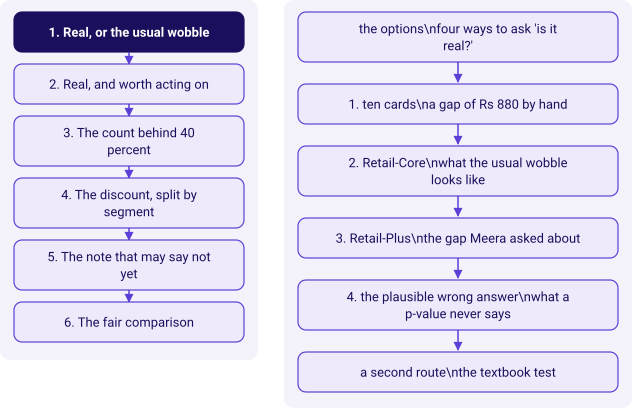

In [2]:
kit.side_by_side(
    kit.ladder(['Real, or the usual wobble', 'Real, and worth acting on', 'The count behind 40 percent', 'The discount, split by segment', 'The note that may say not yet', 'The fair comparison'], lit=0, show=False),
    kit.vflow(["the options\\nfour ways to ask 'is it real?'", '1. ten cards\\na gap of Rs 880 by hand', '2. Retail-Core\\nwhat the usual wobble looks like', '3. Retail-Plus\\nthe gap Meera asked about', '4. the plausible wrong answer\\nwhat a p-value never says', 'a second route\\nthe textbook test'], show=False),
)

## The options

Four ways a team could answer "is the fall real?" before Monday. The sizing cell below times each
one on this file and names what it risks.

| Option | What it does | What it needs |
|---|---|---|
| A. Shuffle test | Deal the quarter labels at random thousands of times and count how often chance makes a gap this large | The member totals and a loop |
| B. Textbook two-sample test | One library call that returns a p-value from a formula about bell-shaped data | A statistics library, and data that behaves like a bell curve |
| C. Bootstrap interval | Redraw each quarter's members many times and read the range of gaps | A loop, and a stakeholder who reads a range |
| D. Wait for Q3 | Look again when another quarter has landed | Thirteen weeks, and a Monday meeting with no answer |

Option,Rows it touches,Time on this file,What it risks
A. Shuffle test,"44 member totals x 5,000 deals",0.09 s,the share moves a few thousandths between seeds
B. Textbook test,"44 member totals, one call",0.003 s,assumes bell-shaped totals; 8 of 44 are zero
C. Bootstrap interval,"44 member totals x 5,000 redraws",0.05 s,"answers how big, and says less about how rare"
D. Wait for Q3,22 more member-quarters,one quarter,Monday passes with no answer


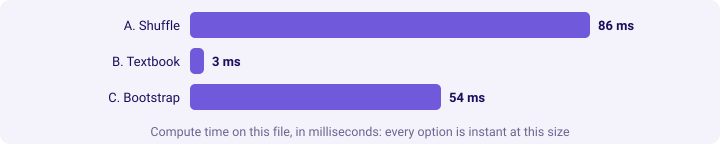

In [3]:
plus_q1, plus_q2 = member_totals("Retail-Plus", "Q1"), member_totals("Retail-Plus", "Q2")
real = mean(plus_q1) - mean(plus_q2)

t0 = time.perf_counter(); a = share_at_least(shuffle_gaps(plus_q1, plus_q2, 5000, seed=2026), real); t_a = time.perf_counter() - t0
from scipy import stats                                   # the textbook route, named today and taught later
t0 = time.perf_counter(); b = stats.ttest_ind(plus_q1, plus_q2, equal_var=False, alternative="greater").pvalue; t_b = time.perf_counter() - t0
t0 = time.perf_counter()
random.seed(2026)
boot = sorted(mean([random.choice(plus_q1) for _ in plus_q1]) - mean([random.choice(plus_q2) for _ in plus_q2]) for _ in range(5000))
t_c = time.perf_counter() - t0
zeros = sum(1 for v in plus_q1 + plus_q2 if v == 0)

rows = [
    ("A. Shuffle test", f"{len(plus_q1) * 2} member totals x 5,000 deals", f"{t_a:.2f} s", "the share moves a few thousandths between seeds"),
    ("B. Textbook test", f"{len(plus_q1) * 2} member totals, one call", f"{t_b:.3f} s", f"assumes bell-shaped totals; {zeros} of 44 are zero"),
    ("C. Bootstrap interval", f"{len(plus_q1) * 2} member totals x 5,000 redraws", f"{t_c:.2f} s", "answers how big, and says less about how rare"),
    ("D. Wait for Q3", "22 more member-quarters", "one quarter", "Monday passes with no answer"),
]
kit.table(["Option", "Rows it touches", "Time on this file", "What it risks"], rows,
          caption="The four options sized on Kalpa's file")
kit.bars([("A. Shuffle", round(t_a * 1000)), ("B. Textbook", max(1, round(t_b * 1000))),
          ("C. Bootstrap", round(t_c * 1000))], fmt=lambda v: f"{v:,} ms",
         title="Compute time on this file, in milliseconds: every option is instant at this size")
kit.check("the three computed options each finish in under five seconds", max(t_a, t_b, t_c) < 5)

**The best-fit call for Meera's Monday: A, the shuffle test.** At 44 member totals every option
runs in well under a second, so compute decides nothing. What decides is the file and the reader:
six members bought nothing in one of the quarters, which is exactly the lumpy shape B's formula
assumes away, and the shuffle can be explained to Meera with ten cards on a table. C comes in
chapter 2, where the question becomes how big. D costs a quarter for a question the data can
already answer.

**The fact that would change the call.** Tens of thousands of members a quarter and a metric that
behaves, which is what a dashboard at Booking.com's scale sees: B then gives the same answer in
one line and is the house standard. And if the shuffle came back unclear, D becomes the honest
answer, because more members is the only thing that sharpens it.

## 1. Ten cards: is a gap of Rs 880 surprising?

Five members' Q1 spend and five members' Q2 spend, **invented for the table**, in rupees. The real
gap is the Q1 mean less the Q2 mean. If the quarter made no difference, the labels are arbitrary:
shuffle the ten cards, deal five to each pile, and the gap you get is one chance-only world. The
room does this by hand before this cell runs.

**Predict before you run.** Out of 1,000 shuffles, how many make a gap of Rs 880 or more?
a) about 500, since half of all gaps are positive; b) about 200; c) about 20; d) none, since 880 is
the real gap and shuffling destroys it.

Q1 mean Rs 3,340, Q2 mean Rs 2,460, real gap Rs 880
the first ten shuffled gaps: [520, 240, -320, 360, 1040, -40, 600, 760, 480, 80]


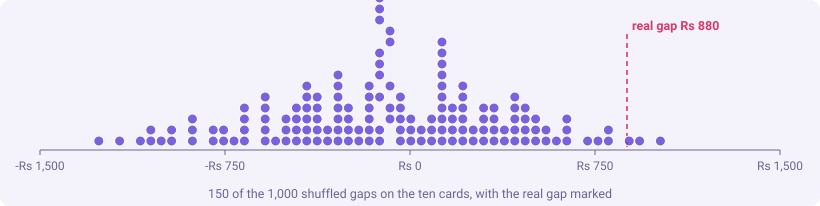

In [4]:
q1_cards = [3400, 2900, 4100, 2500, 3800]
q2_cards = [2200, 3100, 1900, 2700, 2400]
card_gap = mean(q1_cards) - mean(q2_cards)
card_gaps = shuffle_gaps(q1_cards, q2_cards, 1000, seed=2026)
card_share = share_at_least(card_gaps, card_gap)

print(f"Q1 mean Rs {mean(q1_cards):,.0f}, Q2 mean Rs {mean(q2_cards):,.0f}, real gap Rs {card_gap:,.0f}")
print("the first ten shuffled gaps:", [round(g) for g in card_gaps[:10]])
kit.strip(card_gaps[:150], markers=[("real gap", card_gap, "bad")], lo=-1500, hi=1500,
          title="150 of the 1,000 shuffled gaps on the ten cards, with the real gap marked")
kit.stats([("1,000", "shuffles", "the same ten cards"),
           (f"{round(card_share * 1000)}", "gaps of Rs 880 or more", "in chance-only worlds"),
           (f"{card_share:.3f}", "the share", "this is the p-value")])

**What happened.** The answer is c. Twenty-one shuffles in a thousand reached Rs 880, a share of
0.021. Ten hand shuffles showed one in ten, which is why ten is too few: a share needs hundreds of
worlds before it settles. The dots pile up around zero, because most deals mix big and small cards
into both piles, and the real gap sits out on the right edge of the pile.

In [5]:
kit.check("the real gap on the cards is Rs 880", round(card_gap) == 880, f"{card_gap:,.0f}")
kit.check("21 of 1,000 shuffles reach it, with seed 2026", round(card_share * 1000) == 21, f"{card_share:.3f}")

## 2. Retail-Core: what the usual wobble looks like

Before judging Retail-Plus, see an ordinary quarter. Retail-Core members also spent a little less
in Q2. The measure is the day's: delivered revenue per member, one number per member, with a zero
for a member who had no delivered order that quarter.

**Predict before you run.** Retail-Core fell by about Rs 110 per member. What share of 5,000
shuffles will make a gap at least that large? a) under 0.01; b) about 0.05; c) about a third;
d) all of them.

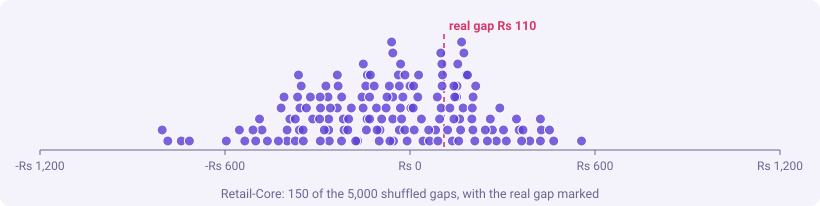

34 members, Q1 Rs 1,509, Q2 Rs 1,399, gap Rs 110; share at least as large 0.345


In [6]:
core_q1, core_q2 = member_totals("Retail-Core", "Q1"), member_totals("Retail-Core", "Q2")
core_gap = mean(core_q1) - mean(core_q2)
core_gaps = shuffle_gaps(core_q1, core_q2, 5000, seed=2026)
core_share = share_at_least(core_gaps, core_gap)
kit.strip(core_gaps[:150], markers=[("real gap", core_gap, "bad")], lo=-1200, hi=1200,
          title="Retail-Core: 150 of the 5,000 shuffled gaps, with the real gap marked")
print(f"{len(core_q1)} members, Q1 Rs {mean(core_q1):,.0f}, Q2 Rs {mean(core_q2):,.0f}, "
      f"gap Rs {core_gap:,.0f}; share at least as large {core_share:.3f}")

**What happened.** The answer is c. About a third of chance-only worlds make a fall of Rs 110 or
more, so Retail-Core's dip is what Meera calls the usual wobble: the real gap sits inside the pile.
Keep this picture, because it is what "nothing happened" looks like.

In [7]:
kit.check("Retail-Core has 34 members in both quarters", len(core_q1) == len(core_q2) == 34)
kit.check("chance makes Retail-Core's gap often", core_share > 0.25, f"{core_share:.3f}")

## 3. Retail-Plus: the gap Meera asked about

The same loop, pointed at the segment in Meera's question.

**Predict before you run.** Compared with Retail-Core's share of about a third, Retail-Plus's share
will be: a) about the same; b) larger, since Retail-Plus is a smaller segment; c) much smaller, if
its fall is bigger than chance makes; d) impossible to compute, since some members have zeros.

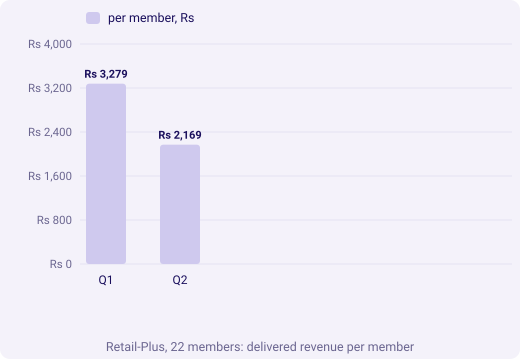

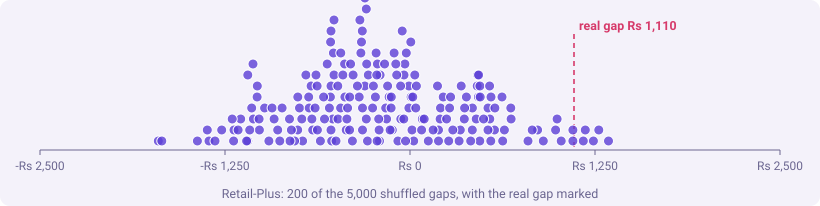

real gap Rs 1,110; 135 of 5,000 at least as large; share 0.027


In [8]:
plus_gaps = shuffle_gaps(plus_q1, plus_q2, 5000, seed=2026)
plus_share = share_at_least(plus_gaps, real)
kit.columns(["Q1", "Q2"], [("per member, Rs", [round(mean(plus_q1)), round(mean(plus_q2))])],
            fmt=kit.rupees, width=520, title=f"Retail-Plus, {len(plus_q1)} members: delivered revenue per member")
kit.strip(plus_gaps[:200], markers=[("real gap", real, "bad")], lo=-2500, hi=2500,
          title="Retail-Plus: 200 of the 5,000 shuffled gaps, with the real gap marked")
print(f"real gap Rs {real:,.0f}; {round(plus_share * 5000)} of 5,000 at least as large; share {plus_share:.3f}")

**What happened.** The answer is c. Retail-Plus members delivered Rs 3,279 each in Q1 and Rs 2,169
in Q2, a fall of Rs 1,110 per member. Only 135 of 5,000 shuffles made a fall that large, a share of
0.027, which reads as 0.03 to two places. Against Retail-Core's third, this is a gap chance rarely
makes, so the first line of the note can say the fall is larger than the usual wobble.

In [9]:
kit.check("Retail-Plus has 22 members in both quarters", len(plus_q1) == len(plus_q2) == 22)
kit.check("the Retail-Plus gap is Rs 1,110 a member", round(real) == 1110, f"{real:.1f}")
kit.check("with seed 2026, 135 of 5,000 shuffles reach it", round(plus_share * 5000) == 135, f"{plus_share:.4f}")
kit.check("Retail-Plus beats the wobble that Retail-Core sits inside", plus_share < 0.05 < core_share)

## 4. The plausible wrong answer

**The plausible wrong answer.** The hurried draft turns the share straight into a sentence about
being wrong. Here it is, computed exactly the way it gets written, and the decision it invites is
Meera treating the fall as 97 percent certain and funding a fix on that basis.

In [10]:
draft = f"p = {plus_share:.2f}, so there is a {plus_share:.0%} chance we are wrong about the drop."
print(draft)

p = 0.03, so there is a 3% chance we are wrong about the drop.


**Why it is wrong.** Every one of the 5,000 shuffles was dealt in a world where the quarter made no
difference. The share counts how often *that* world makes a fall this large. It says nothing about
the chance that this finding is wrong, which depends on things the shuffle never saw: how plausible
a fall was before the data, what else changed, and how many segments were tested.

**The check.** Build twenty **invented** segments in which nothing changed at all, both quarters
drawn from the same range, and run the same test on each. Any segment that comes back small is a
finding that is wrong for certain, whatever its share says.

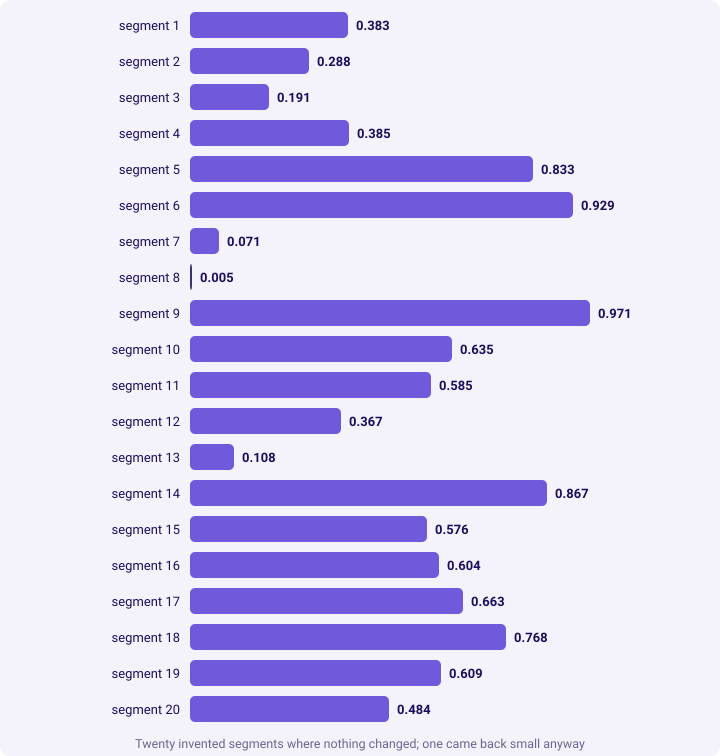

1 of 20 came back at 0.05 or below: [0.005]


In [11]:
invented_shares = []
for s in range(20):
    maker = random.Random(100 + s)                       # invented members, same range both quarters
    values = [maker.randint(1500, 4500) for _ in range(40)]
    q1, q2 = values[:20], values[20:]
    invented_shares.append(share_at_least(shuffle_gaps(q1, q2, 1000, seed=2026), mean(q1) - mean(q2)))

small = [p for p in invented_shares if p <= 0.05]
kit.bars([(f"segment {i + 1}", round(p, 3)) for i, p in enumerate(invented_shares)],
         lit=[i for i, p in enumerate(invented_shares) if p <= 0.05], fmt=lambda v: f"{v:.3f}",
         title="Twenty invented segments where nothing changed; one came back small anyway")
print(f"{len(small)} of 20 came back at 0.05 or below: {small}")

One invented segment came back at 0.005 although nothing happened in it. Its draft note would say
"a 0.5 percent chance we are wrong", and it would be wrong with certainty.

**The fix.** Say the share, the world it was counted in, and what it lets you conclude.

If nothing had changed between the quarters, a fall of Rs 1,110 per member or more would turn up in about 3 of every 100 shuffles, so we treat the Retail-Plus drop as real.


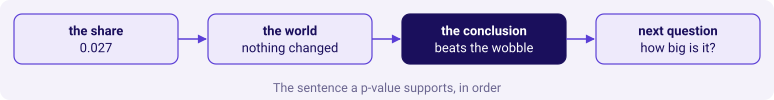

In [12]:
fixed = (f"If nothing had changed between the quarters, a fall of Rs {real:,.0f} per member or more "
         f"would turn up in about {round(plus_share * 100)} of every 100 shuffles, so we treat the Retail-Plus drop as real.")
print(fixed)
kit.flow(["the share\n" + f"{plus_share:.3f}", "the world\nnothing changed", "the conclusion\nbeats the wobble",
          "next question\nhow big is it?"], lit=2, title="The sentence a p-value supports, in order")
kit.check("the fixed sentence names the chance-only world", fixed.startswith("If nothing had changed"))
kit.check("one of twenty no-change segments still came back small", len(small) == 1, f"{small}")

What changed: the number is the same 0.027, and the claim shrank from "97 percent certain" to
"larger than the usual wobble". That is the claim the evidence carries.

## A second route: the textbook test

Option B, run now as the cross-check. The library call is the two-sample test a statistics course
teaches first; its formula is for a later week, and today it is a second opinion.

**Predict before you run.** The textbook test's p-value for Retail-Plus will be: a) about 0.03, the
same verdict; b) about 0.3, the opposite verdict; c) exactly 0.027, since it is the same method;
d) impossible, since the totals are not bell-shaped.

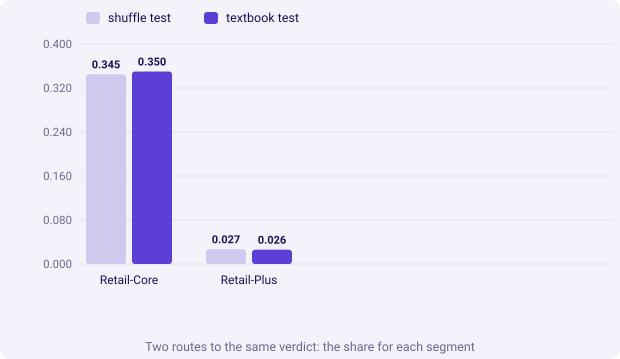

Retail-Plus: shuffle 0.027, textbook 0.026; Retail-Core: shuffle 0.345, textbook 0.350


In [13]:
text_plus = stats.ttest_ind(plus_q1, plus_q2, equal_var=False, alternative="greater").pvalue
text_core = stats.ttest_ind(core_q1, core_q2, equal_var=False, alternative="greater").pvalue
kit.columns(["Retail-Core", "Retail-Plus"],
            [("shuffle test", [round(core_share, 3), round(plus_share, 3)]),
             ("textbook test", [round(text_core, 3), round(text_plus, 3)])],
            fmt=lambda v: f"{v:.3f}", width=620, title="Two routes to the same verdict: the share for each segment")
print(f"Retail-Plus: shuffle {plus_share:.3f}, textbook {text_plus:.3f}; Retail-Core: shuffle {core_share:.3f}, textbook {text_core:.3f}")
kit.check("the two routes agree on Retail-Plus within a hundredth", abs(text_plus - plus_share) < 0.01,
          f"{plus_share:.3f} against {text_plus:.3f}")
kit.check("the two routes agree on Retail-Core's verdict", text_core > 0.25 and core_share > 0.25)

**What happened.** The answer is a. The textbook test says 0.026 where the shuffle said 0.027, and
both put Retail-Core near a third. Two routes built on different ideas reach one verdict, so the
note can carry it. **When to switch.** Use the textbook call when the data is large and
well-behaved and a team standard expects it; keep the shuffle when the data is small or lumpy, or
when the person reading the answer needs to see how it was made.

> **Kavya's review.** "Retail-Core's third is the baseline, Retail-Plus's 0.03 is the gap against
> it, the textbook test agrees, and your sentence would still be true if the drop turned out to be
> a fluke. Now tell me how much money it is."

### In the interview

**[S] What does p = 0.03 mean, and not mean?** "It means that if there were no real difference, a
difference at least as large as the one we saw would turn up about 3 times in 100 by chance alone.
It does not mean there is a 3 percent chance the finding is wrong, and it does not say the effect is
large or worth acting on. I say it as: chance rarely makes a gap this big, so I treat it as real,
and then I size it." The interviewer is listening for the conditional, "if there were no
difference", and for the refusal to call it the probability of being wrong.

**[S] How do you know whether a change in a metric is significant?** "I build a reference for what
chance alone does. The simplest is a shuffle test: pool the values from the two periods, deal them
back at random thousands of times, and see how often the shuffled gap is as large as the real one.
If that share is small, the change is bigger than the usual wobble. Then I check the count behind it
and size it in money, because significant only means larger than noise."

**[D] A shuffle test, a textbook test, or wait a quarter: which do you run for a CEO's Monday, and
what would make you switch?** "On a few dozen customers with lumpy spend, the shuffle: it runs in a
second, assumes nothing about shape and I can show it with cards. I cross-check with the textbook
test. I would make the textbook test the default on large, well-behaved data, and I would wait a
quarter only if both came back unclear, because then more data is the only thing that helps."

### Depth: one direction or both

The chapter counted falls at least as large, because Meera asked about a drop. Counting falls *or*
rises at least as large asks whether chance makes a move this big in either direction, and it
roughly doubles the share. A note that tested both directions says so.

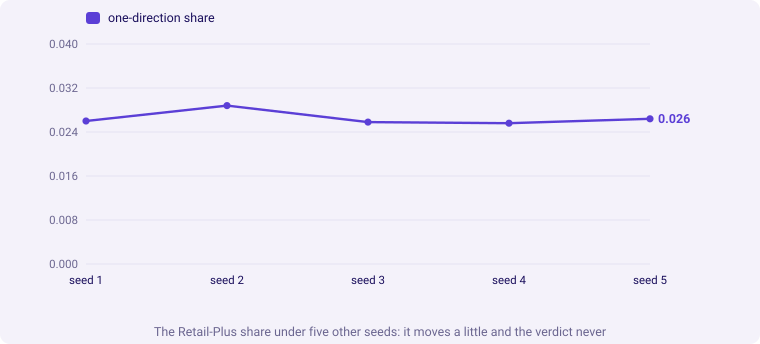

both directions 0.050; five seeds [0.026, 0.0288, 0.0258, 0.0256, 0.0264]


In [14]:
both = sum(1 for g in plus_gaps if abs(g) >= abs(real)) / len(plus_gaps)
seeds = [round(share_at_least(shuffle_gaps(plus_q1, plus_q2, 5000, seed=s), real), 4) for s in (1, 2, 3, 4, 5)]
kit.line([f"seed {s}" for s in (1, 2, 3, 4, 5)], [("one-direction share", seeds, "plain")], lo=0,
         fmt=lambda v: f"{v:.3f}", title="The Retail-Plus share under five other seeds: it moves a little and the verdict never")
print(f"both directions {both:.3f}; five seeds {seeds}")
kit.check("counting both directions roughly doubles the share", 1.6 < both / plus_share < 2.4, f"{both:.3f}")
kit.check("another seed never changes the verdict", all(0.02 < s < 0.035 for s in seeds), f"{seeds}")

In [15]:
kit.check_summary()
print("Next: chapter 2. The drop beats the wobble; is it worth acting on?")

Next: chapter 2. The drop beats the wobble; is it worth acting on?
